In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import flexiznam as flz
import sys
from cottage_analysis.preprocessing import synchronisation
from cottage_analysis.analysis.gratings import generate_trials_df
from cottage_analysis.analysis.gratings import analyze_grating_responses

In [11]:
project_name = "toksozi_in-vivo-BRISC"
mouse_name   = "BRAC12106.1c"
session_name = "S20251223"
protocol     = "SFTF"

print(f"Configuration Loaded: {mouse_name} / {session_name}")

Configuration Loaded: BRAC12106.1c / S20251223


In [12]:
def find_recordings(p_name, m_name, s_name, proto, base_dir="/Volumes/lab-znamenskiyp/home/shared/projects/"):
    base_path = Path(base_dir)
    session_path = base_path / p_name / m_name / s_name
    
    if not session_path.exists():
        print(f"[ERROR] Path not found: {session_path}")
        return None, None, None

    print(f"\nLooking for recordings in: {session_path}")
    recordings = sorted([p for p in session_path.iterdir() if p.is_dir() and p.name.startswith("R")])
    
    if not recordings:
        print("[WARNING] No recordings found starting with 'R' in this session folder.")
        return None, None, None

    print(f"Found {len(recordings)} recording(s).")
    flexiznam_session_id = f"{m_name}_{s_name}"
    
    return p_name, flexiznam_session_id, proto


In [13]:
def run_analysis(project_name, session_id, protocol):
    if not project_name or not session_id:
        print("Invalid project or session ID. Aborting analysis.")
        return

    print(f"\n>>> Starting {protocol} analysis for {session_id}...")
    
    try:
        trials_df, dff_mean_all = analyze_grating_responses(
            project=project_name,
            session=session_id,
            protocol_base=protocol
        )
        
        print("\n>>> Analysis Complete!")
        print(f"Result: Trials DataFrame with shape {trials_df.shape}")

        return trials_df, dff_mean_all

    except Exception as e:
        print(f"\n[ERROR] Analysis failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None


Looking for recordings in: /Volumes/lab-znamenskiyp/home/shared/projects/toksozi_in-vivo-BRISC/BRAC12106.1c/S20251223
Found 1 recording(s).

>>> Starting SFTF analysis for BRAC12106.1c_S20251223...


/Users/toksozi/code/cottage_analysis/cottage_analysis/io_module/harp.py:129: UserWarning: No di_names provided or found in extra_attributes. Using default.
  warnings.warn(


Saving harp messages into npz...


Reading harp messages: 100%|█████████▉| 143M/143M [00:56<00:00, 2.55Mbits/s]    
/Users/toksozi/code/cottage_analysis/cottage_analysis/io_module/harp.py:215: UserWarning: Could not find any reward!
  warnings.warn("Could not find any reward!")


Harp messages saved.
Recording is 8524 s long.
Frame rate is 143 Hz.
Found 1214842 frames out of 1225871 render (0.90%, 11029 dropped)
Starting crosscorrelation


100%|██████████| 1214842/1214842 [04:37<00:00, 4370.52it/s]

done (278 s)


Adding cross correlation results to dataframe
Matching fit to logger
Sync'ed 1201047 frames easily. That's 98% of the recording.
6549 frames cannot be sync'ed. That's 0.5% of the recording.
Sync'ed 2489 frames based on relative peak corr coeff. That's 0.2% of the recording.
Sync'ed 4757 frames based on photodiode value. That's 0.4% of the recording.
done (19 s)
70 frames of by one and will be fixed 27.6%
37 frames are double and will be removed. That's 14.6% of the cases where the closest frame is the same.
Found 1180297 consensus frames
Found 1139589 frames with residuals < 0.08
Found 1208094 frames with non-nan closest_frame
1128799/1214805 frames left for interpolation
Found 0 out of order frames
1128799/1214805 frames left
Found 0 out of order frames and 530 frames matching the same index after interpolation
70 frames of by one and will be fixed 13.2%
36 frames are double and will be removed. That's 6.8% of the cases where the closest frame is the same.
Plotting diagnostic figures


,imaging_harptime,imaging_frame,imaging_volume,imaging_harptime_end,monitor_frame,monitor_harptime,mouse_z,eye_z,stimulus_harptime,Frameindex,...,TemporalFrequency,Angle,Phase,mouse_z_harptime,mouse_z_harp,dffs,stim_start,stim_end,dff_stim,irecording
0,1.519335e+07,728,104,1.519335e+07,5755,1.519335e+07,-0.04,-0.04,1.519335e+07,5733.0,...,8.0,315.0,0.0,1.519335e+07,-0.000460,"[[-0.11638089541515118, -0.07919124350080207, ...",106,123.0,"[[0.19747116626850425, 0.3804913364310248, 0.1...",BRAC12106.1c_S20251223_R123258_SFTF
1,1.519336e+07,847,121,1.519336e+07,6326,1.519336e+07,-0.02,-0.02,1.519335e+07,6308.0,...,0.5,90.0,0.0,1.519336e+07,-0.000153,"[[0.023339741523655318, 0.9858329585319585, -0...",123,140.0,"[[0.6275581098766465, 0.884463656865804, -0.46...",BRAC12106.1c_S20251223_R123258_SFTF
2,1.519336e+07,966,138,1.519336e+07,6898,1.519336e+07,-0.01,-0.01,1.519336e+07,6884.0,...,0.5,270.0,0.0,1.519336e+07,0.000153,"[[0.37819595216371754, -0.24438474536085797, -...",140,157.0,"[[0.14983778537813008, -0.4624046644297833, -0...",BRAC12106.1c_S20251223_R123258_SFTF
3,1.519336e+07,1085,155,1.519336e+07,7469,1.519336e+07,0.02,0.02,1.519336e+07,7459.0,...,0.5,135.0,0.0,1.519336e+07,0.000153,"[[0.5366758193345498, 0.24013346542316302, 0.2...",157,174.0,"[[0.016163846168147224, 0.2521235198981159, 0....",BRAC12106.1c_S20251223_R123258_SFTF
4,1.519337e+07,1204,172,1.519337e+07,8039,1.519337e+07,0.02,0.02,1.519337e+07,8035.0,...,0.5,180.0,0.0,1.519337e+07,0.000460,"[[-0.0787516198517549, 0.1545963408268563, -0....",174,191.0,"[[0.32109607016490455, 0.5752190150030885, 0.2...",BRAC12106.1c_S20251223_R123258_SFTF


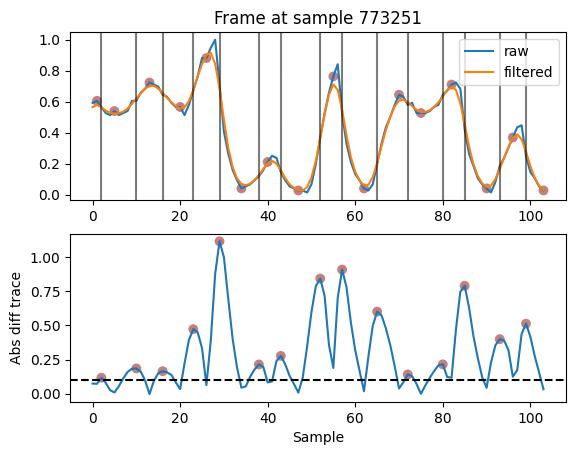

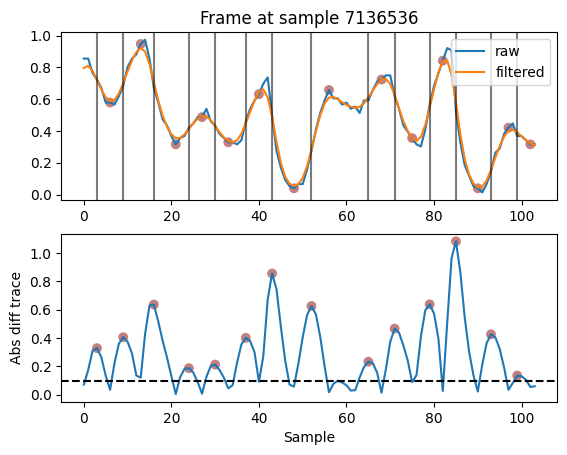

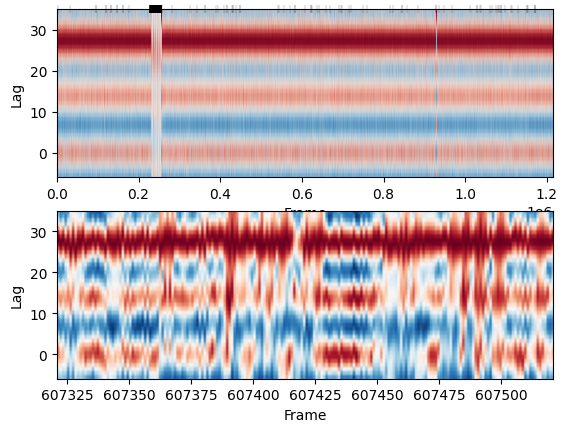

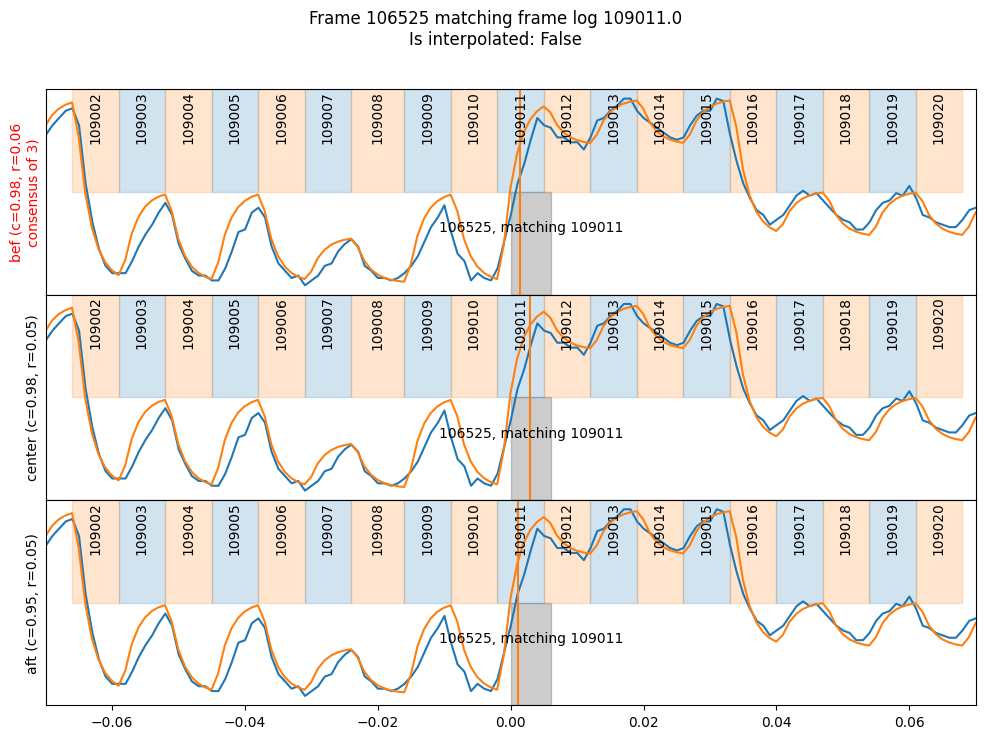

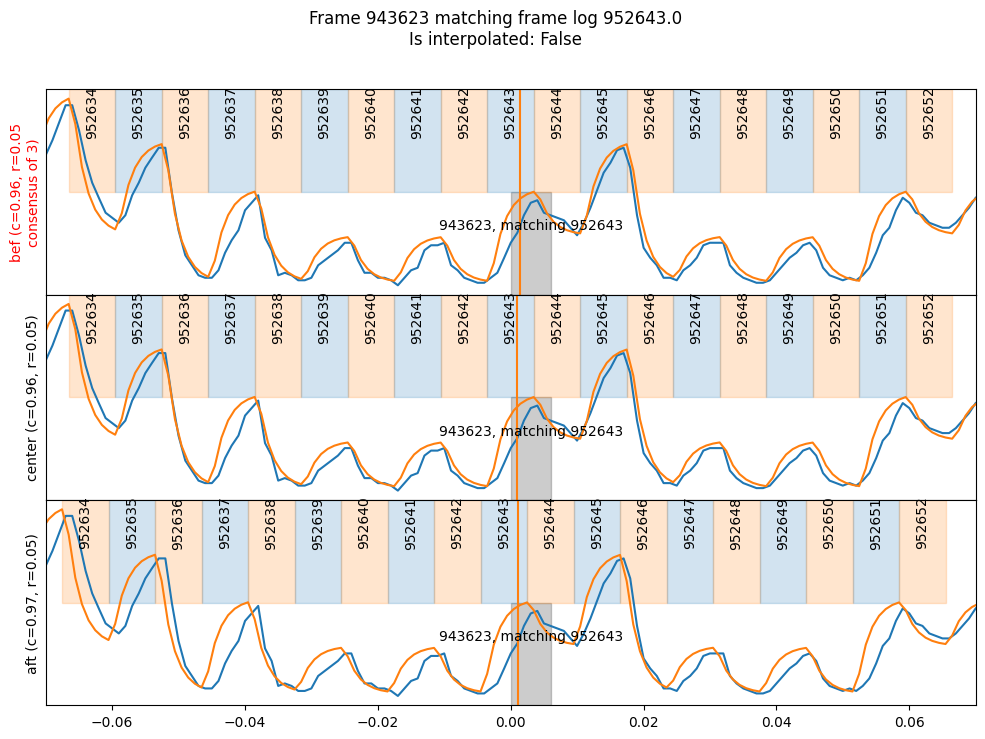

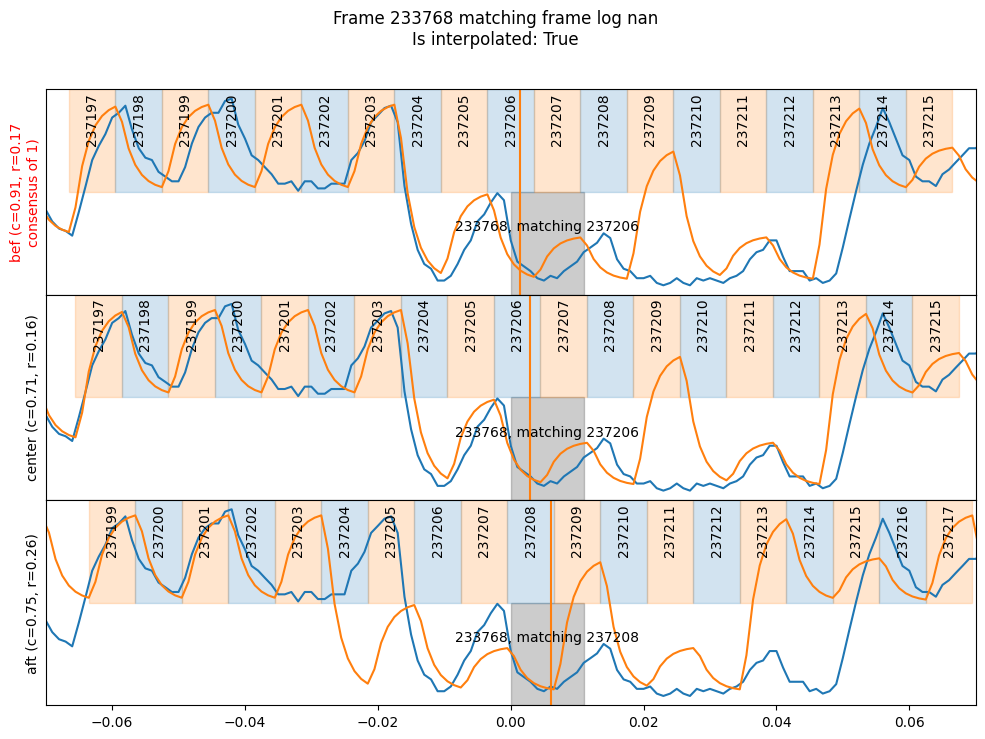

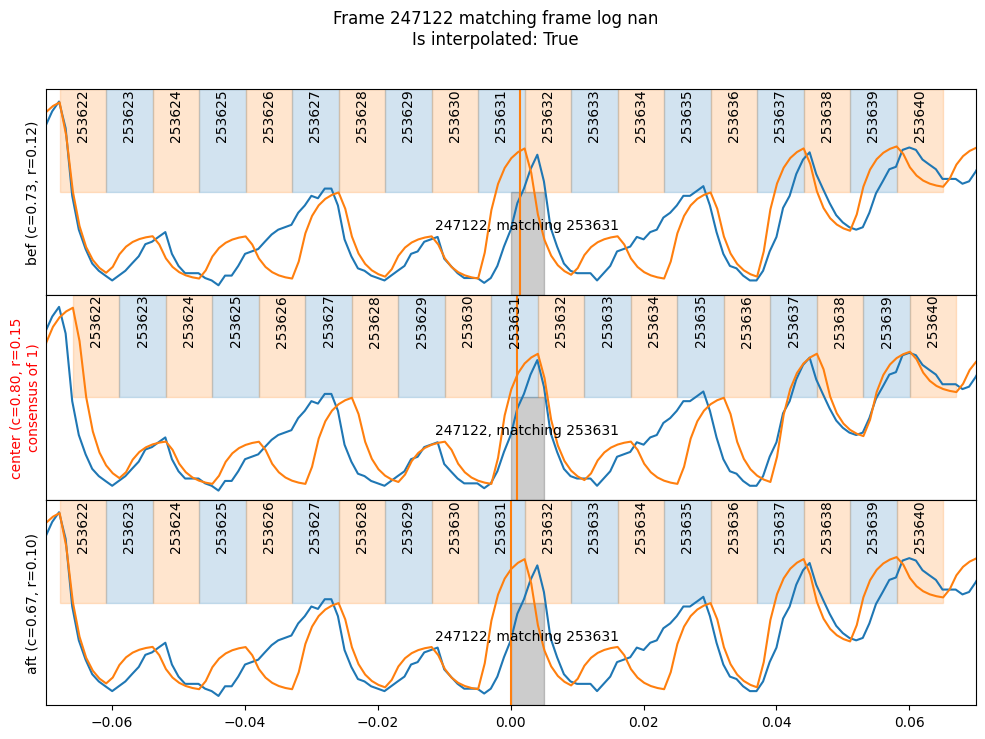

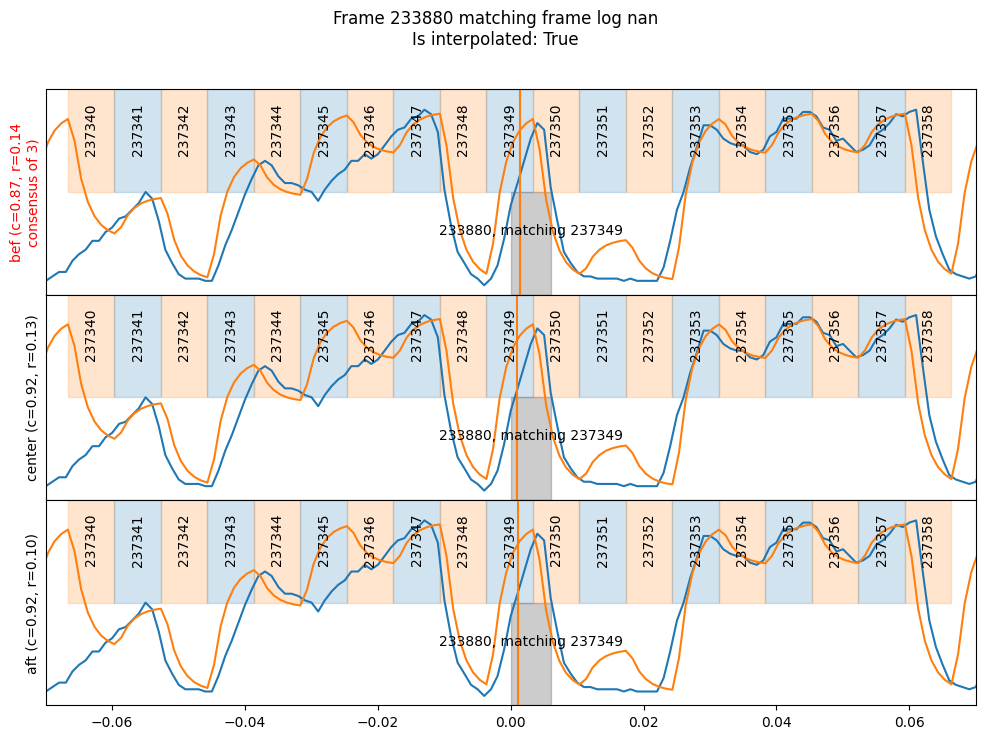

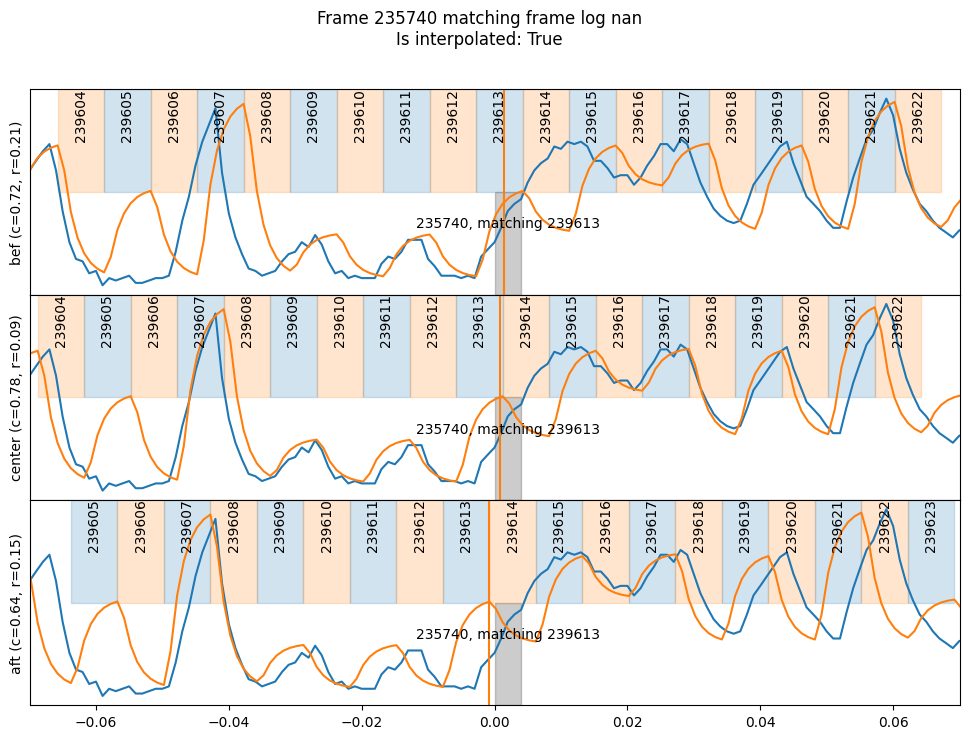

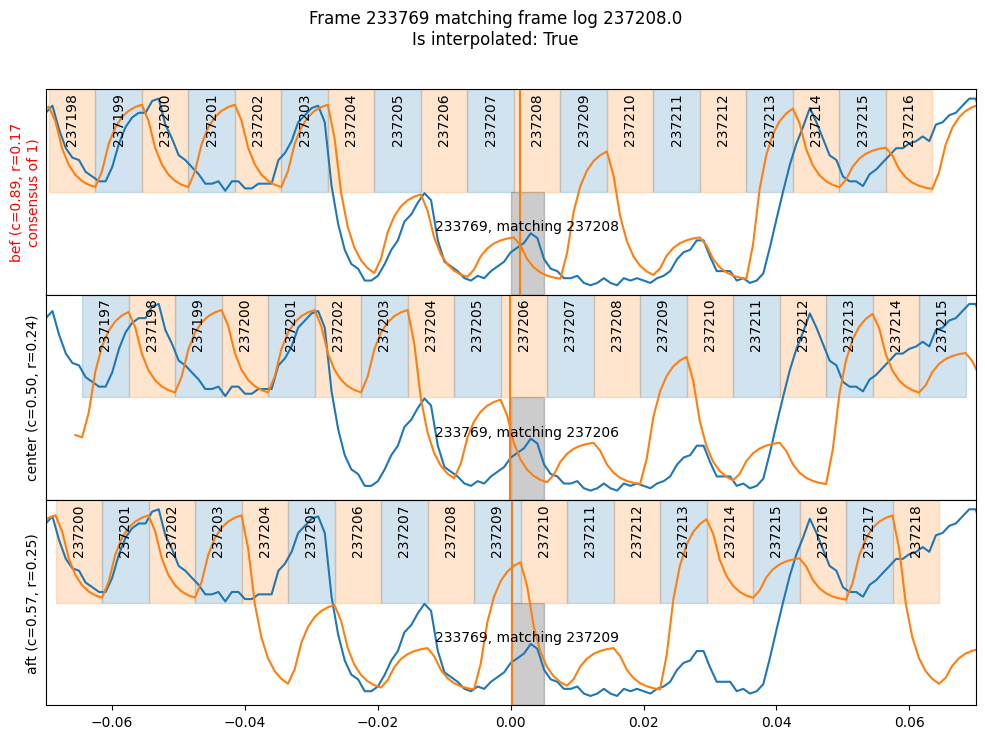

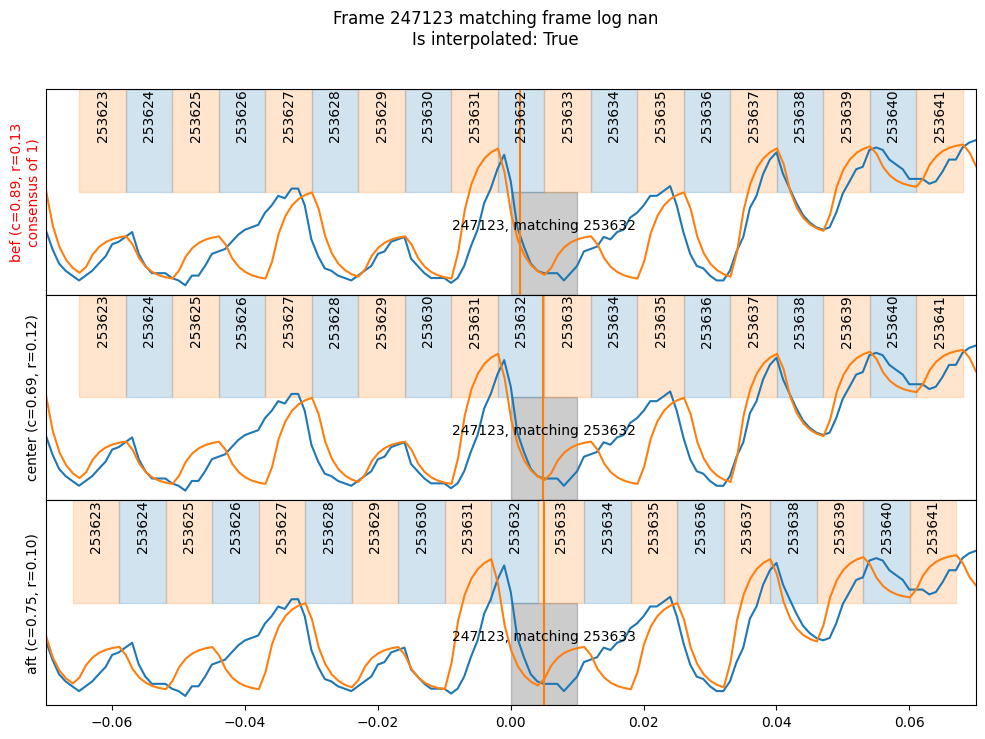

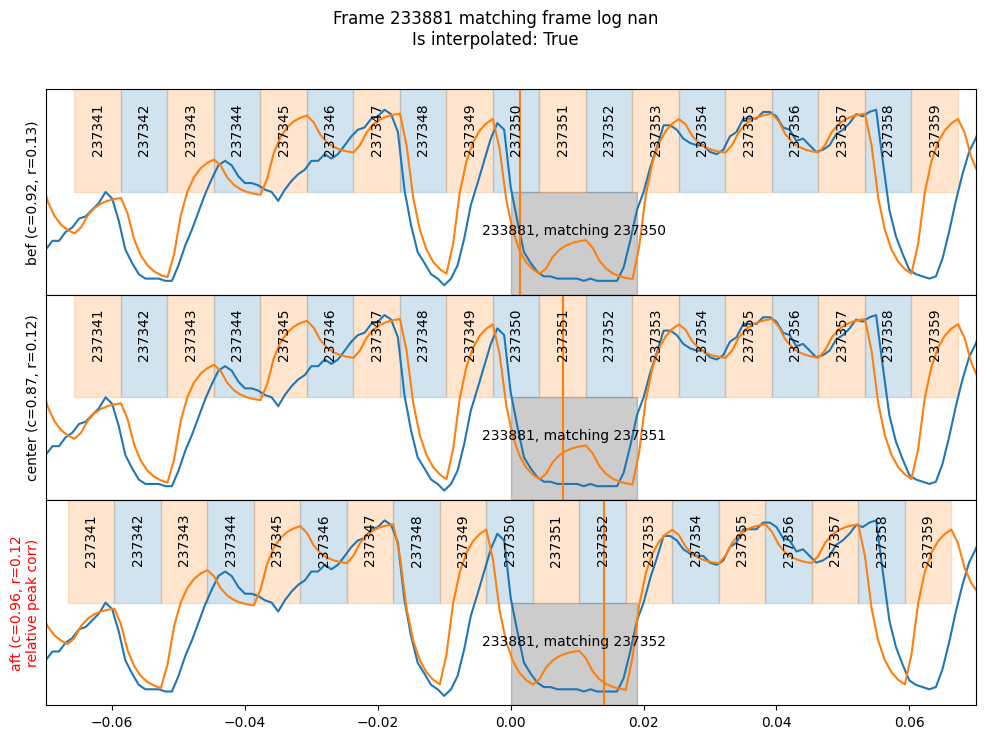

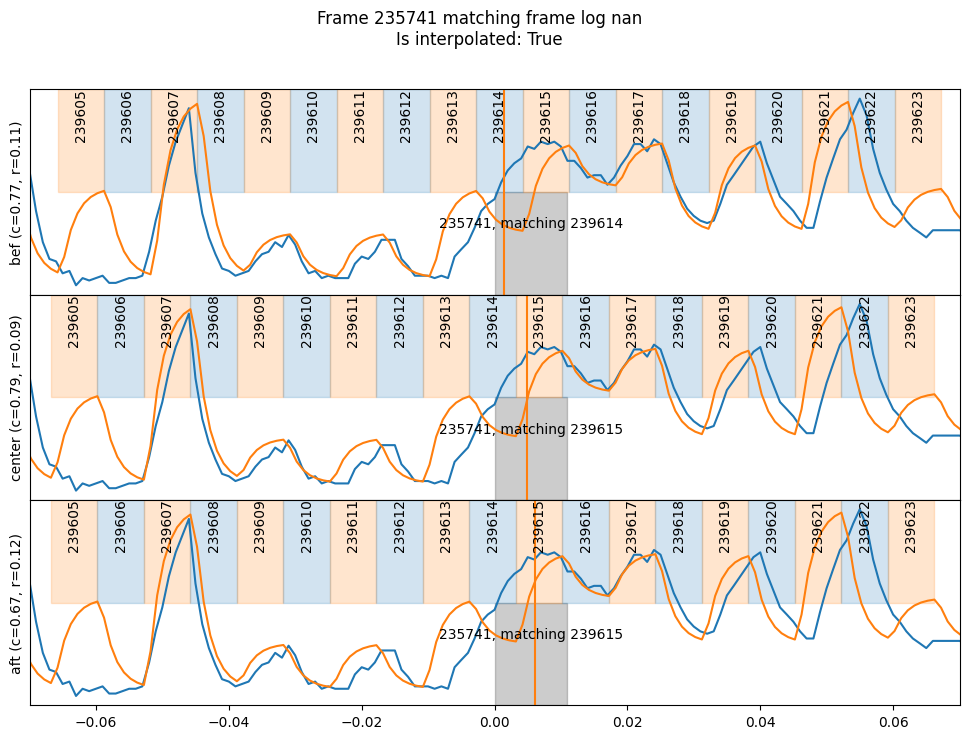

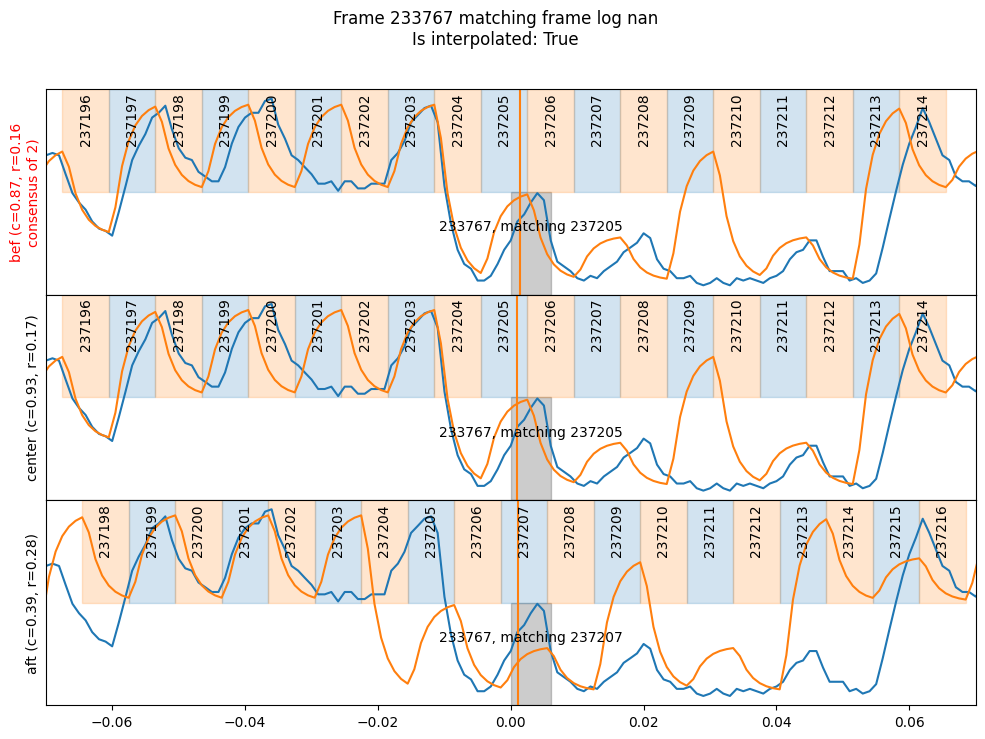

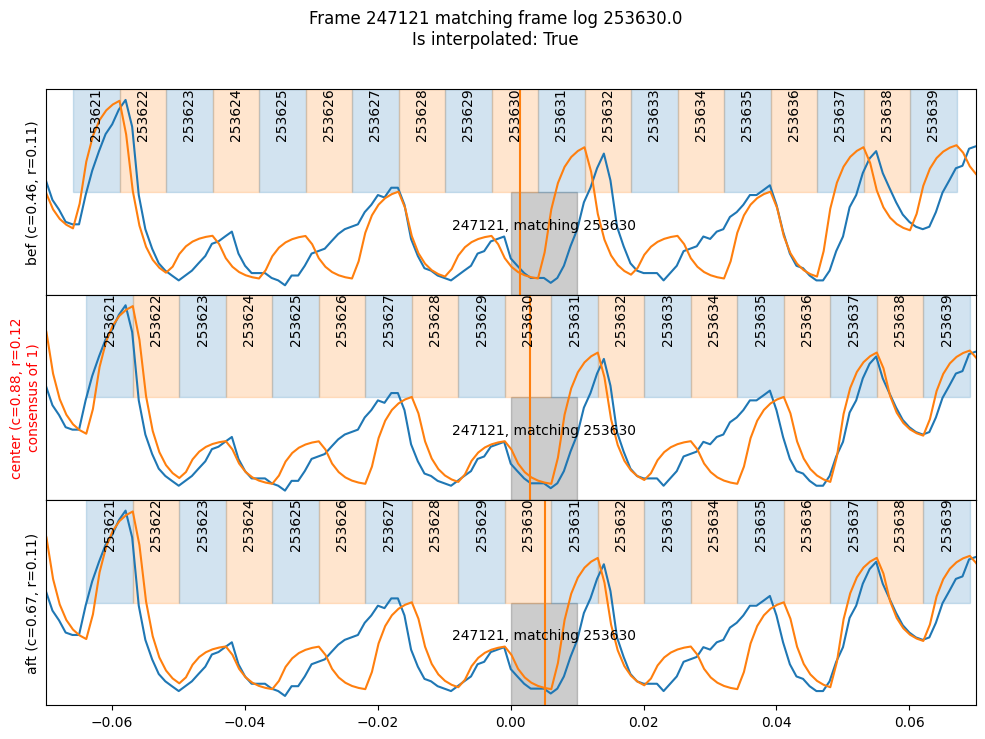

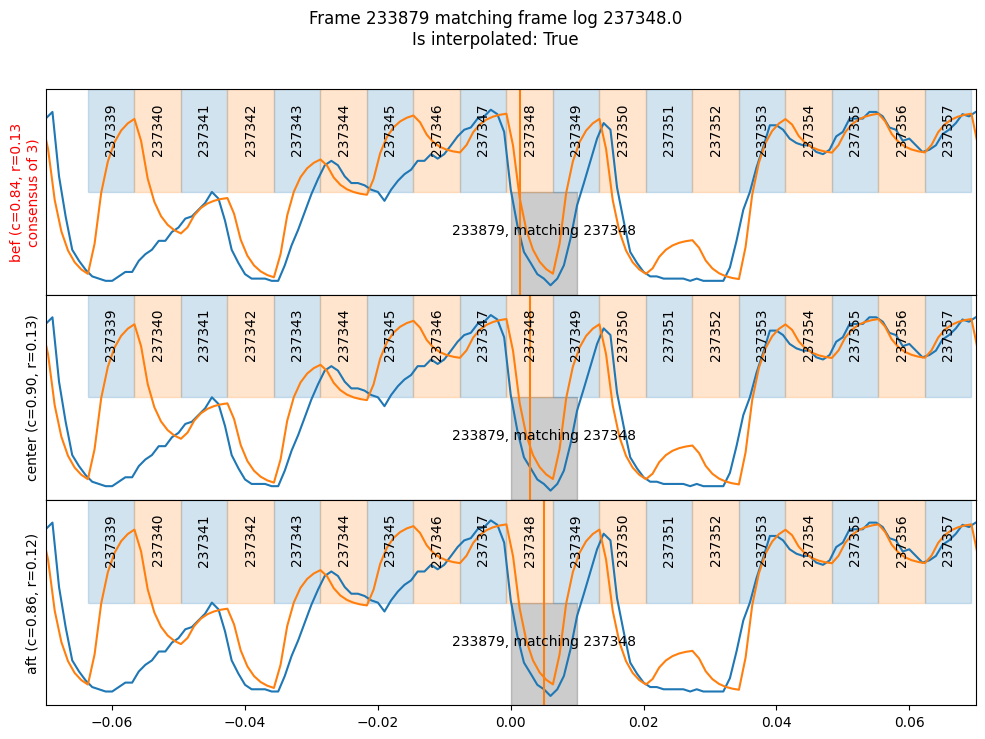

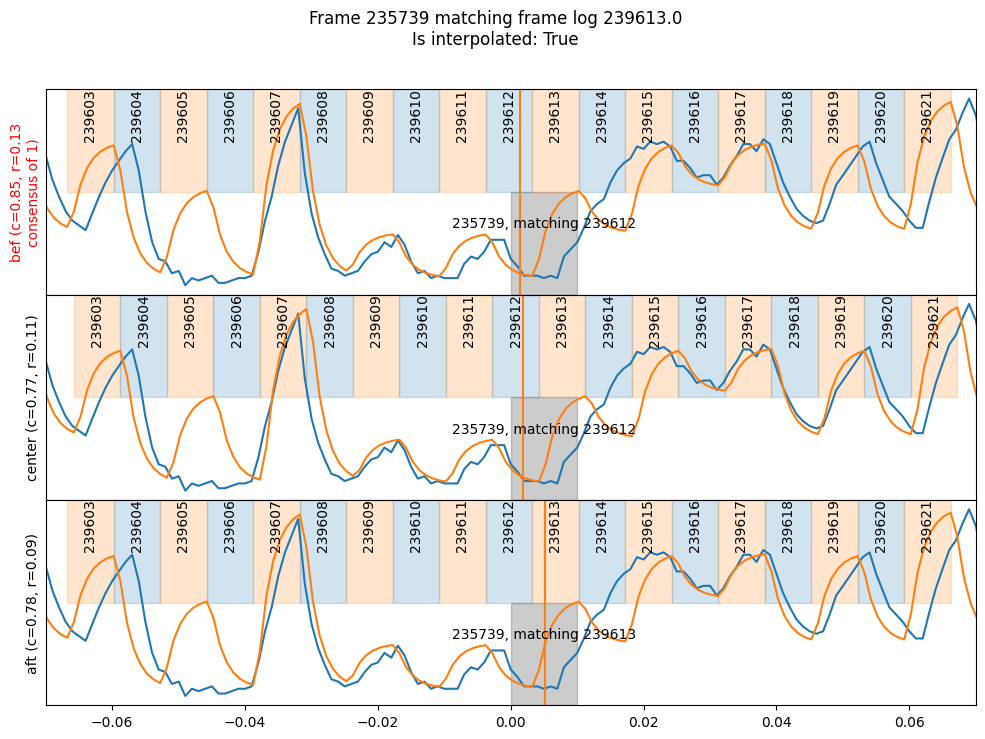

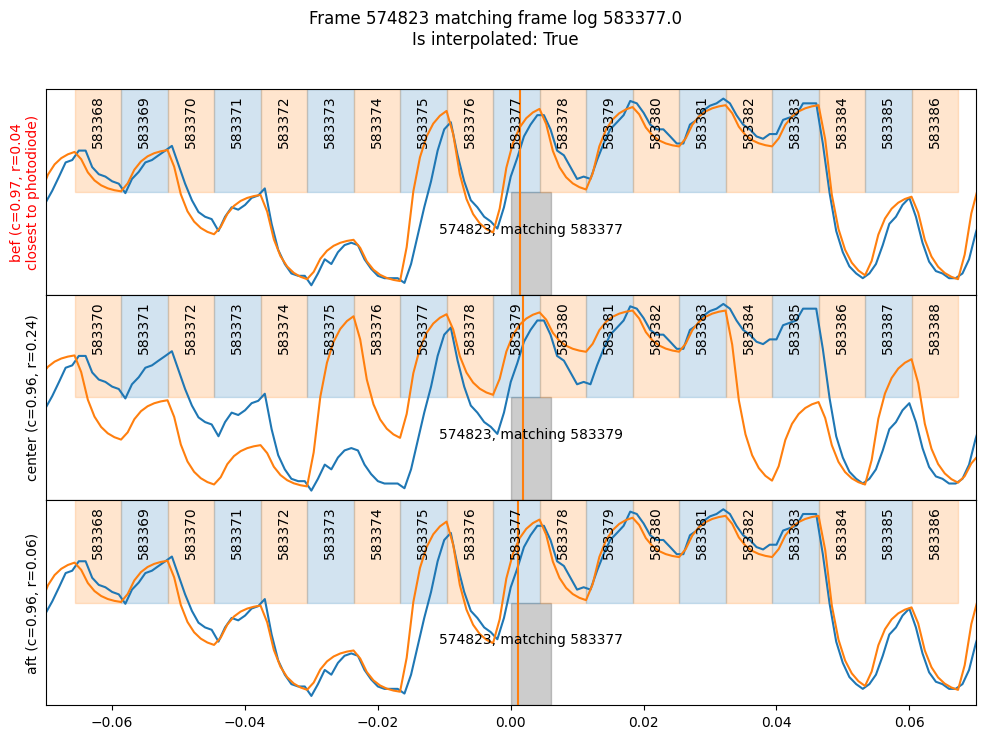

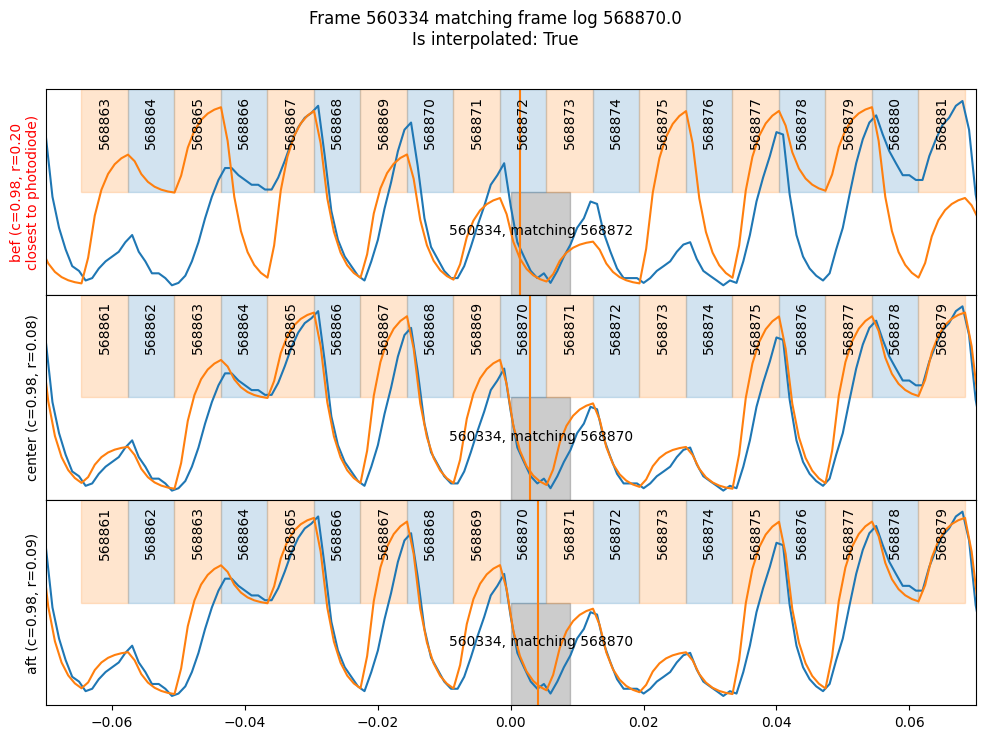

In [14]:
if __name__ == "__main__":
    # Find the recordings
    proj, sess_id, proto = find_recordings(project_name, mouse_name, session_name, protocol)
    
    # If valid recordings were found, run the analysis
    if proj and sess_id:
        trials_df, dff_mean = run_analysis(proj, sess_id, proto)
    
    print("\nFirst 5 rows of your data:")
    display(trials_df.head())

    

In [16]:
import pandas as pd
import numpy as np
from cottage_analysis.analysis.fit_gaussian_blob import fit_sftf_tuning
import os

base_save_dir = Path("analysis_dataframes")
save_path = base_save_dir / mouse_name / session_name / protocol
save_path.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {save_path.resolve()}")
neurons_file = save_path / "neurons_df.pkl"

if neurons_file.exists():
    print("Found saved data! Loading from disk...")
    neurons_df = pd.read_pickle(neurons_file)
    print(f"Loaded {len(neurons_df)} neurons from: {save_path}")

    if 'trials_df' not in locals():
        print("WARNING: 'neurons_df' loaded, but 'trials_df' is missing.")
        print("Run previous kernel to generate the trials dataframe.")
    else:
        print("'trials_df' is present in memory.")

elif 'trials_df' not in locals():
    print("ERROR: 'trials_df' is missing.")
    print("Please make sure you ran the analysis successfully.")


else:
    print(f"No data found in {save_path}")
    print("Running full analysis...")

    # Stack turns the list of arrays into a big matrix (Trials x Neurons)
    response_matrix = np.stack(trials_df['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)

    # Create a DataFrame with integer column names (0, 1, 2...)
    # These integers effectively become the "ROI IDs"
    responses_df = pd.DataFrame(
        response_matrix, 
        columns=np.arange(response_matrix.shape[1]), 
        index=trials_df.index
    )

    # Combine with the stimulus information
    # We keep the original stimulus columns and add the new neuron columns
    trials_df_formatted = pd.concat(
        [trials_df[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], 
        axis=1
    )

    print(f"Data formatted! New shape: {trials_df_formatted.shape}")
    print(f" (Should be approx {len(trials_df)} rows x {response_matrix.shape[1] + 3} columns)")

    # Run the fit on the formatted data
    try:
        print("\nFitting Gaussian blobs... (This may take 1-5 minutes)")
        neurons_df = fit_sftf_tuning(trials_df_formatted, niter=3)
        print("\nFitting complete!")
        print(f"Neurons DataFrame shape: {neurons_df.shape}")
        display(neurons_df.head())

        print(f"Saving neurons dataframe to: {save_path}")
        neurons_df.to_pickle(neurons_file)
        print("Analysis complete and saved.")
    except:
        print(f"The fitter got stuck. Error: {e}")
        print("Your data might be too noisy for the default bounds.")

Working directory: /Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/analysis_dataframes/BRAC12106.1c/S20251223/SFTF
No data found in analysis_dataframes/BRAC12106.1c/S20251223/SFTF
Running full analysis...
Data formatted! New shape: (2120, 2207)
 (Should be approx 2120 rows x 2207 columns)

Fitting Gaussian blobs... (This may take 1-5 minutes)


  0%|          | 0/2204 [00:00<?, ?it/s]/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:98: RuntimeWarning: overflow encountered in exp
  sigma_x_sq = np.exp(log_sigma_x2) + min_sigma
  5%|▍         | 101/2204 [00:17<04:08,  8.47it/s]/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:342: RuntimeWarning: overflow encountered in exp
  resp = np.exp(kappa * np.cos(alpha - alpha0)) + (1 - dsi) * np.exp(
/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:345: RuntimeWarning: overflow encountered in exp
  peak_resp = np.exp(kappa) + (1 - dsi) * np.exp(-kappa)
/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:346: RuntimeWarning: invalid value encountered in divide
  return resp / peak_resp
  8%|▊         | 170/2204 [00:36<03:32,  9.56it/s]/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:99: RuntimeWarning: overflow encount


Fitting complete!
Neurons DataFrame shape: (2204, 11)


,log_amplitude,sf0,tf0,log_sigma_x2,log_sigma_y2,theta,offset,alpha0,log_kappa,dsi,rsq
0,-2.625656,-1.396717,-0.296084,-16.399626,1.698515,3.936194e-22,0.073563,1.772253,0.470720,1.321821e-19,0.048397
1,-2.592240,-0.139434,-1.693147,14.696054,0.545030,3.751718e-01,0.205861,1.919771,0.592653,5.741857e-01,0.005869
2,-2.195024,-3.786863,0.704722,-1.391555,0.009455,7.419488e-01,0.170145,1.687948,1.680513,7.586856e-01,0.025617
3,-1.981823,-1.748181,0.834096,-1.285887,1.278936,4.976133e-02,0.050411,4.174758,-1.951363,1.000000e+00,0.145950
4,-2.116483,-3.617547,1.610987,0.441776,1.400632,2.449442e-12,0.050409,4.184552,-0.607283,1.690137e-01,0.159911


Saving neurons dataframe to: analysis_dataframes/BRAC12106.1c/S20251223/SFTF
Analysis complete and saved.


Data already ready.
Plotting ROI 1133 (R2: 0.04)


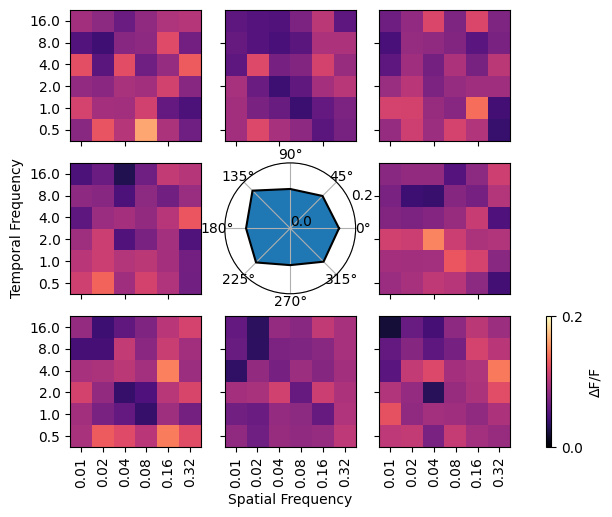

Plotting ROI 1134 (R2: 0.10)


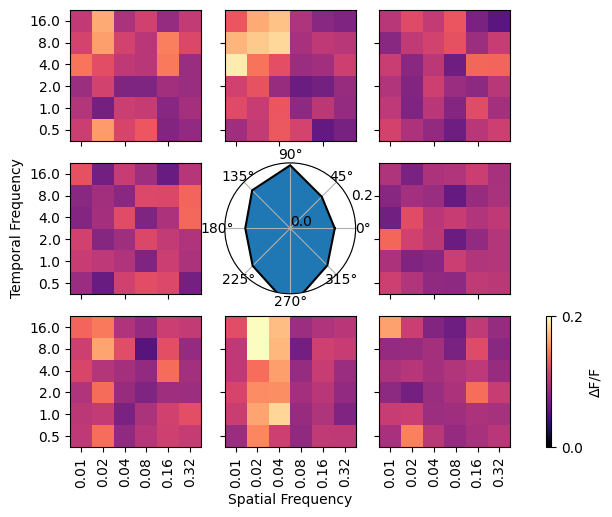

Plotting ROI 1135 (R2: 0.17)


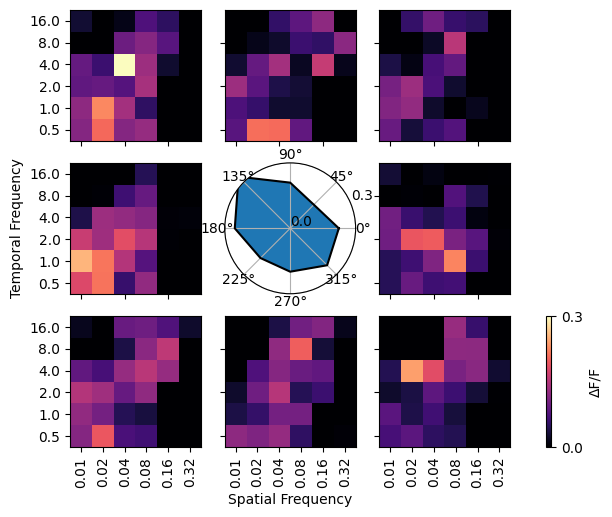

Plotting ROI 1136 (R2: 0.19)


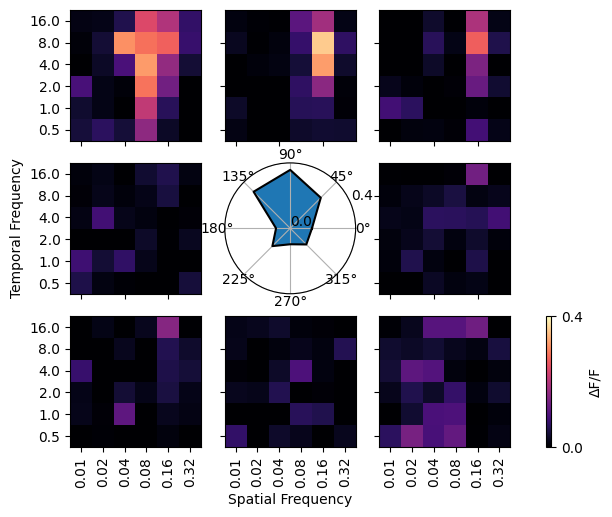

Plotting ROI 1137 (R2: 0.14)


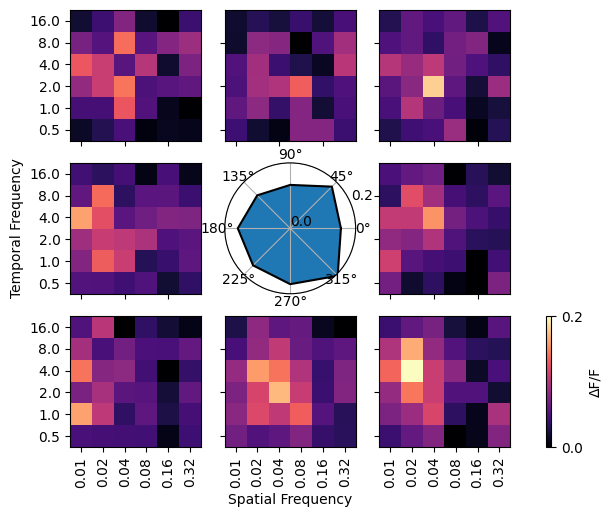

Plotting ROI 1138 (R2: 0.02)


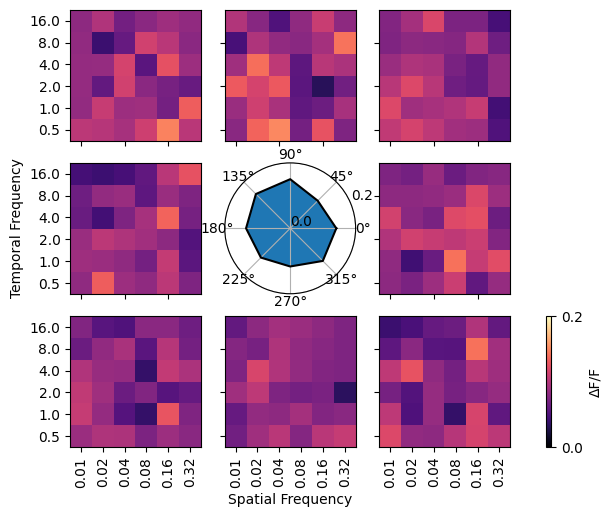

Plotting ROI 1139 (R2: 0.29)


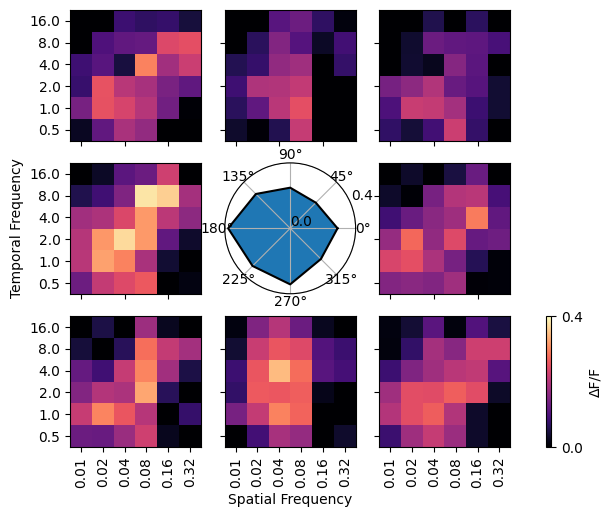

Plotting ROI 1140 (R2: 0.20)


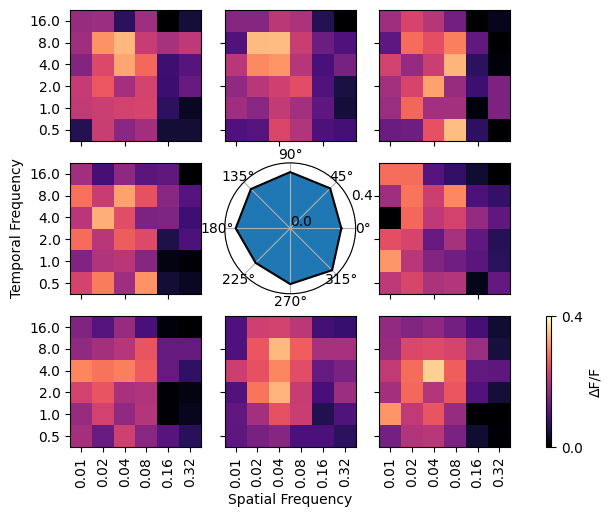

Plotting ROI 1141 (R2: 0.14)


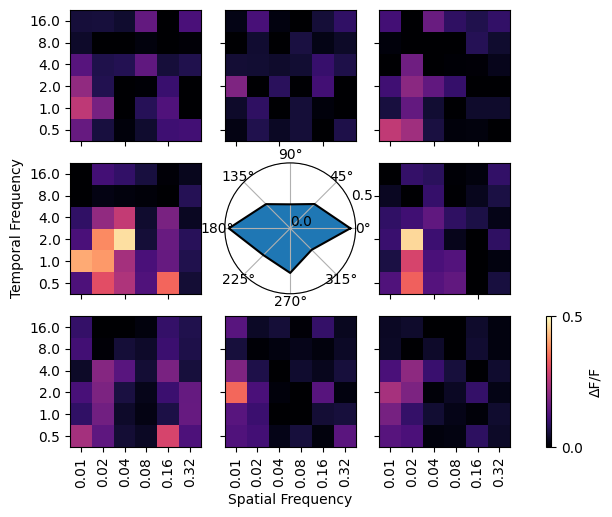

Plotting ROI 1142 (R2: 0.07)


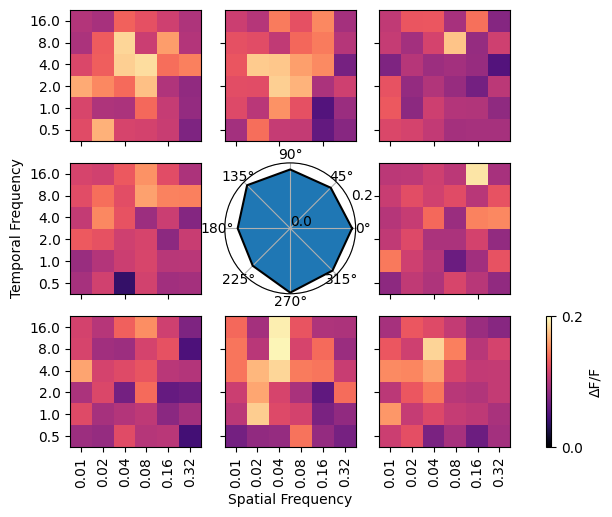

Plotting ROI 1143 (R2: 0.02)


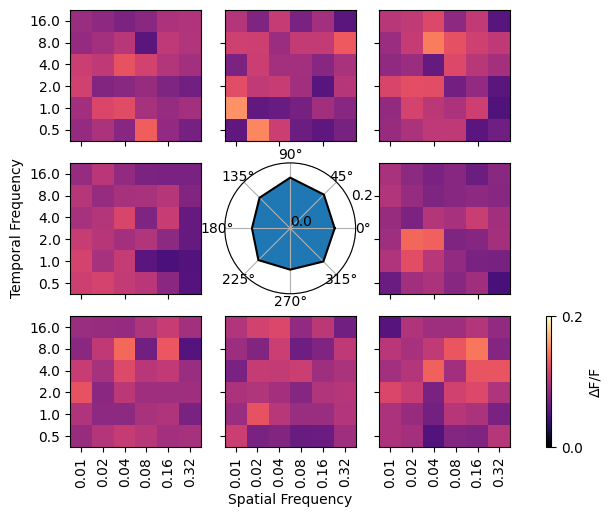

Plotting ROI 1144 (R2: 0.06)


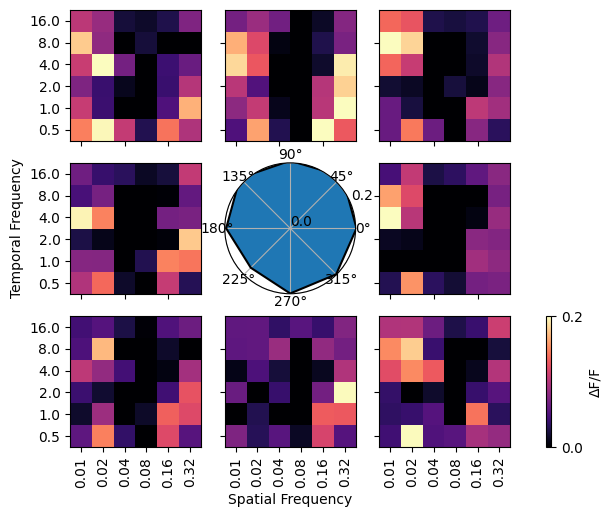

Plotting ROI 1145 (R2: 0.29)


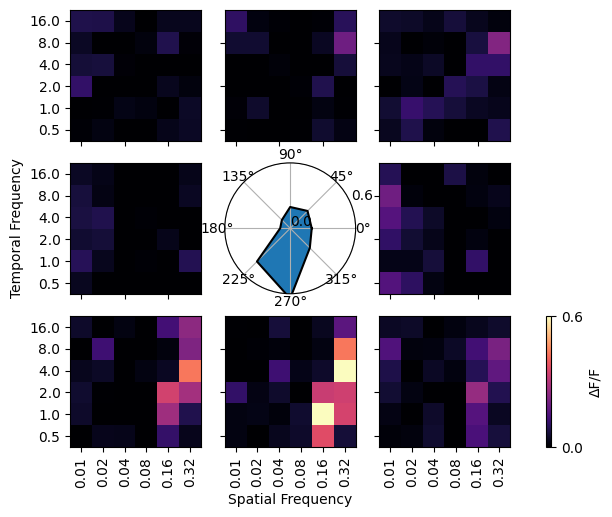

Plotting ROI 1146 (R2: 0.07)


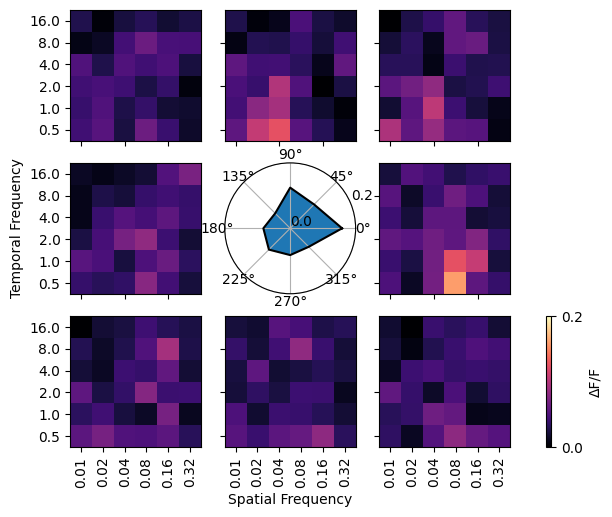

Plotting ROI 1147 (R2: 0.05)


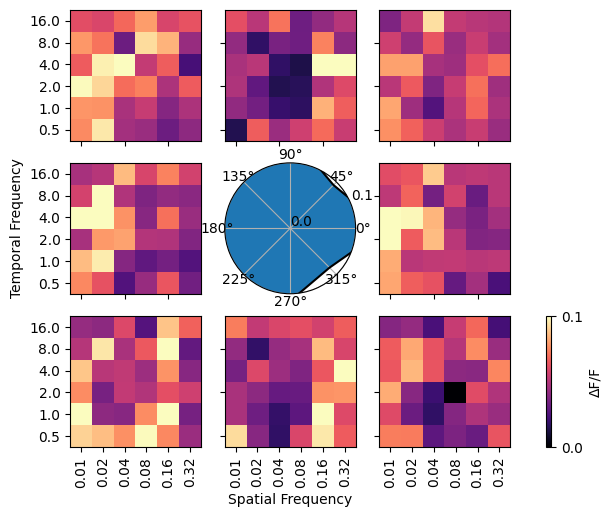

Plotting ROI 1148 (R2: 0.12)


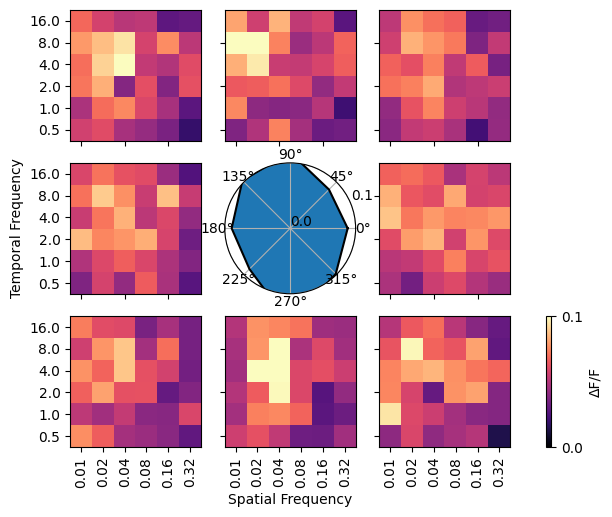

Plotting ROI 1149 (R2: 0.02)


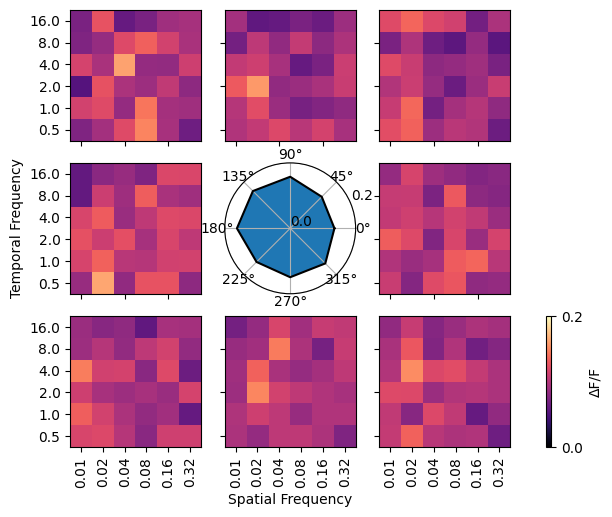

Plotting ROI 1150 (R2: 0.07)


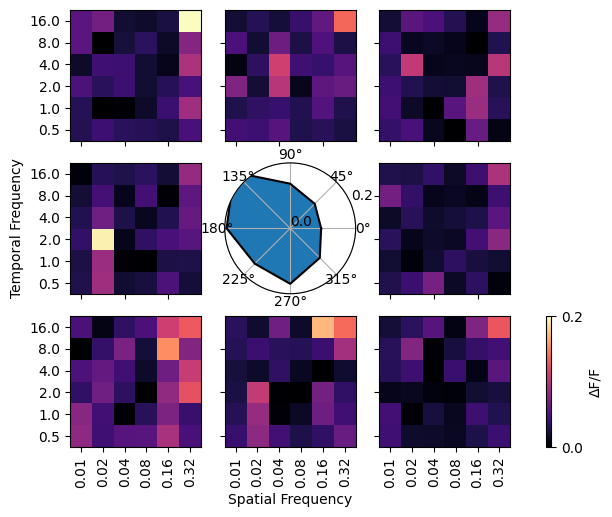

Plotting ROI 1151 (R2: 0.33)


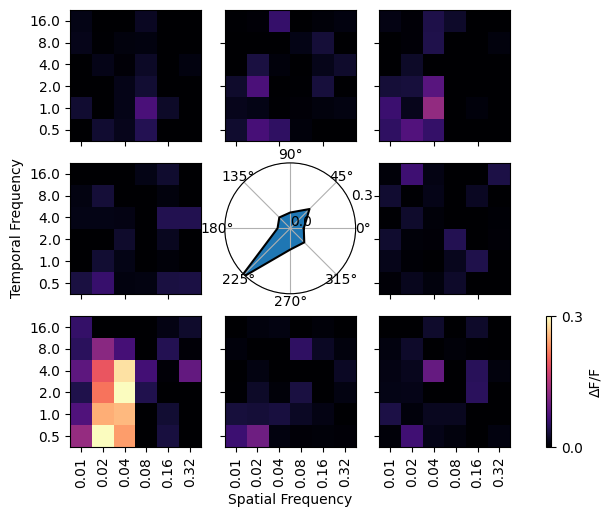

Plotting ROI 1152 (R2: 0.31)


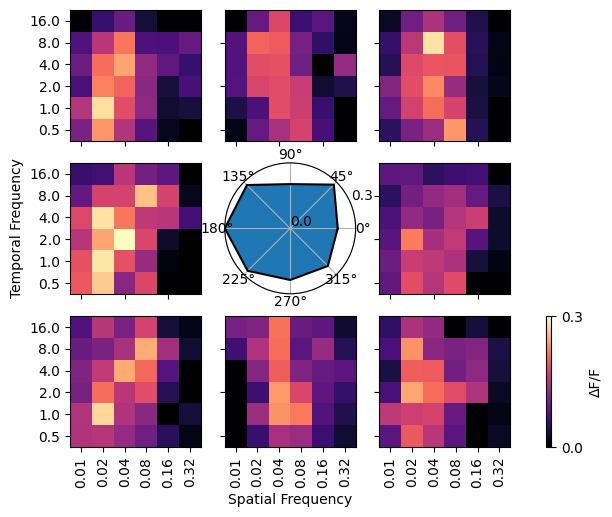

Plotting ROI 1153 (R2: 0.08)


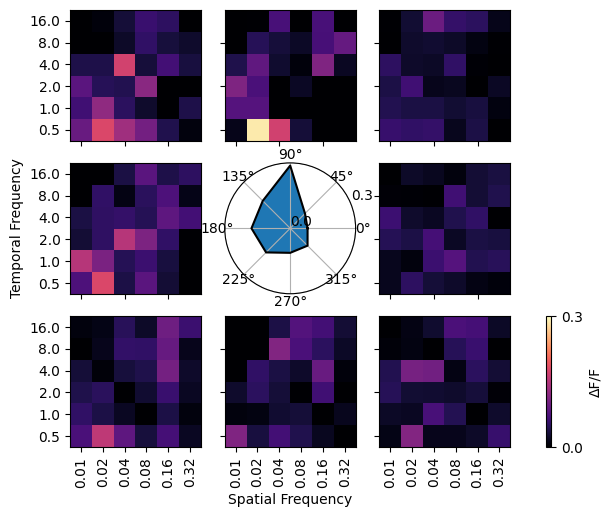

Plotting ROI 1154 (R2: 0.11)


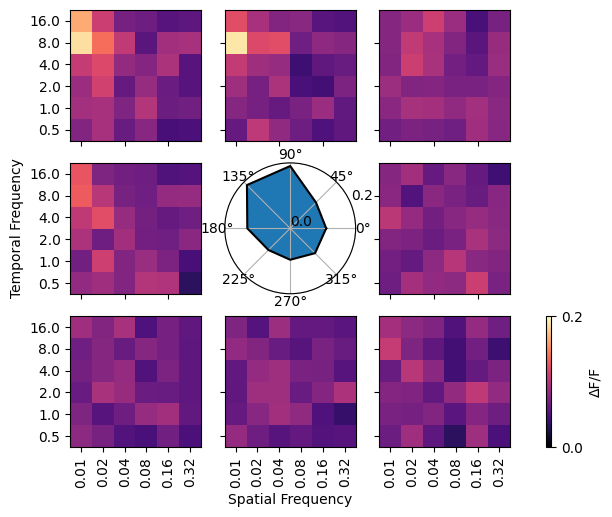

Plotting ROI 1155 (R2: 0.18)


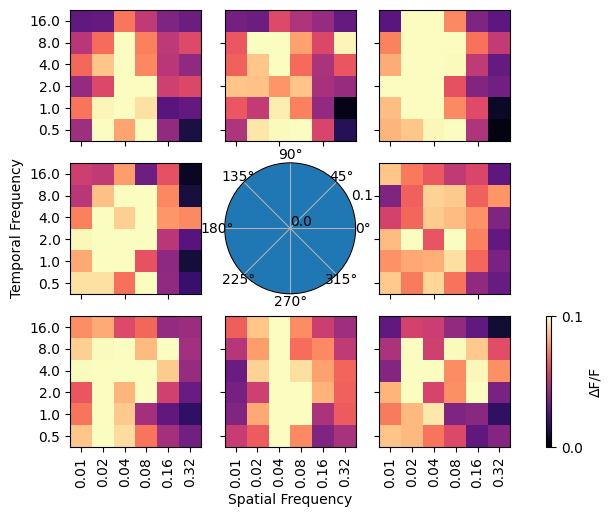

Plotting ROI 1156 (R2: 0.06)


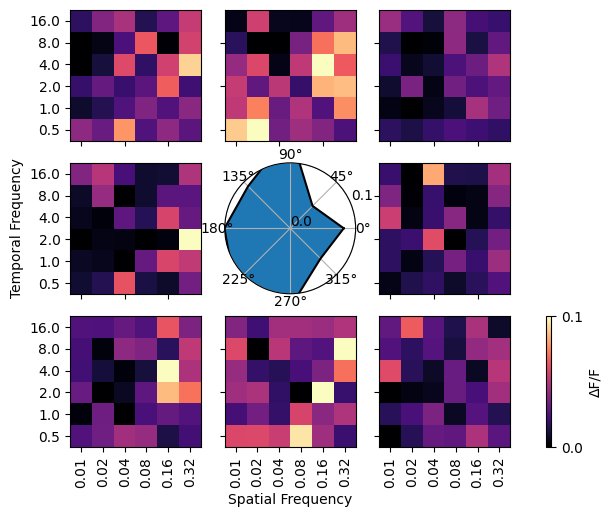

Plotting ROI 1157 (R2: 0.11)


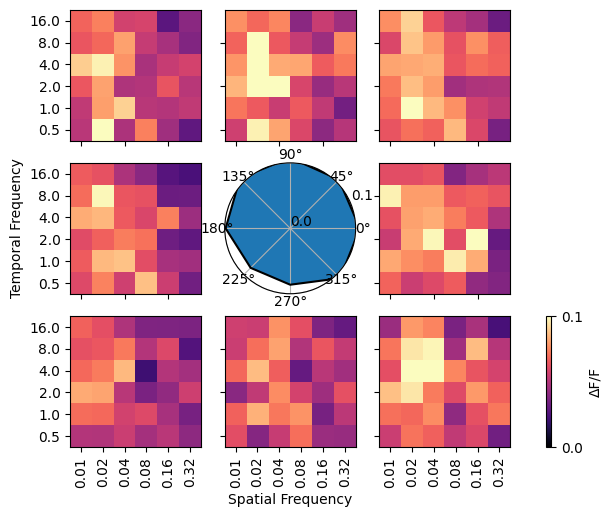

Plotting ROI 1158 (R2: 0.05)


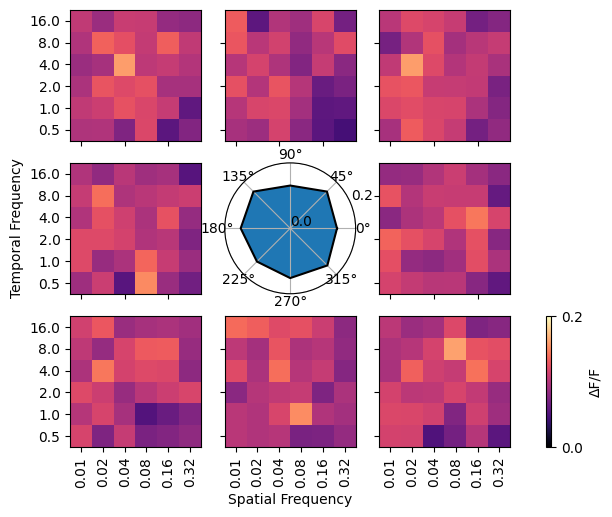

Plotting ROI 1159 (R2: 0.02)


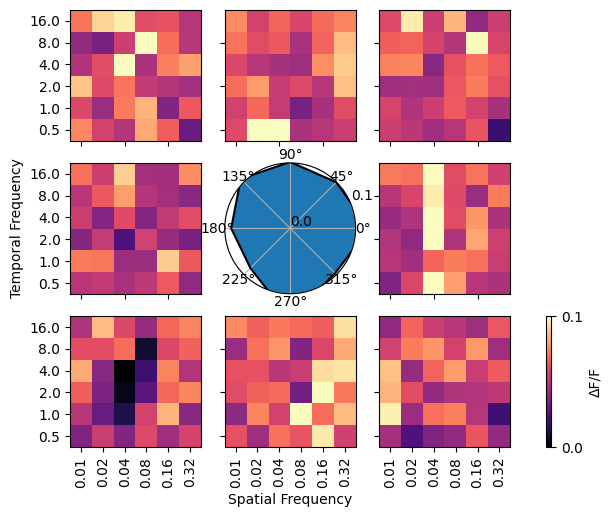

In [17]:
from cottage_analysis.plotting import grating_plots
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

base_save_dir = Path("analysis_dataframes")
save_path = base_save_dir / mouse_name / session_name / protocol
neurons_file = save_path / "neurons_df.pkl"

if 'trials_df' not in locals():
    raise FileNotFoundError("'trials_df' is missing from memory. Please run previous kernels to generate it.")

# Check if we have the fitted results
if 'neurons_df' not in locals():
    if neurons_file.exists():
        print("Loading neurons_df from disk...")
        neurons_df = pd.read_pickle(neurons_file)
    else:
        raise FileNotFoundError(f"No neurons_df found at {save_path}. Run Kernel 6 first.")

# If the formatted version (for plotting) is missing, create it now
if 'trials_df_formatted' not in locals():
    print("Formatting trials dataframe for plotting...")
    response_matrix = np.stack(trials_df['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)
    
    responses_df = pd.DataFrame(
        response_matrix, 
        columns=np.arange(response_matrix.shape[1]), 
        index=trials_df.index
    )
    
    trials_df_formatted = pd.concat(
        [trials_df[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], 
        axis=1
    )
    print("Data formatted and ready.")
else:
    print("Data already ready.")

for found_rois in range(1133, 1160):
    # Safety check: ensure ROI exists in the data
    if found_rois not in neurons_df.index:
        print(f"Skipping ROI {found_rois} (Not found in data)")
        continue

    rsq = neurons_df.loc[found_rois, 'rsq']
    print(f"Plotting ROI {found_rois} (R2: {rsq:.2f})")

    plt.figure(figsize=(5, 5))

    # Now this is guaranteed to work
    grating_plots.plot_sftf_tuning(
        trials_df=trials_df_formatted, 
        roi=found_rois,
        plot_grid=True 
    )

    plt.show()



Generating full report for ROI 1159...


/Users/toksozi/code/cottage_analysis/cottage_analysis/plotting/grating_plots.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.005)


<Figure size 1500x1000 with 0 Axes>

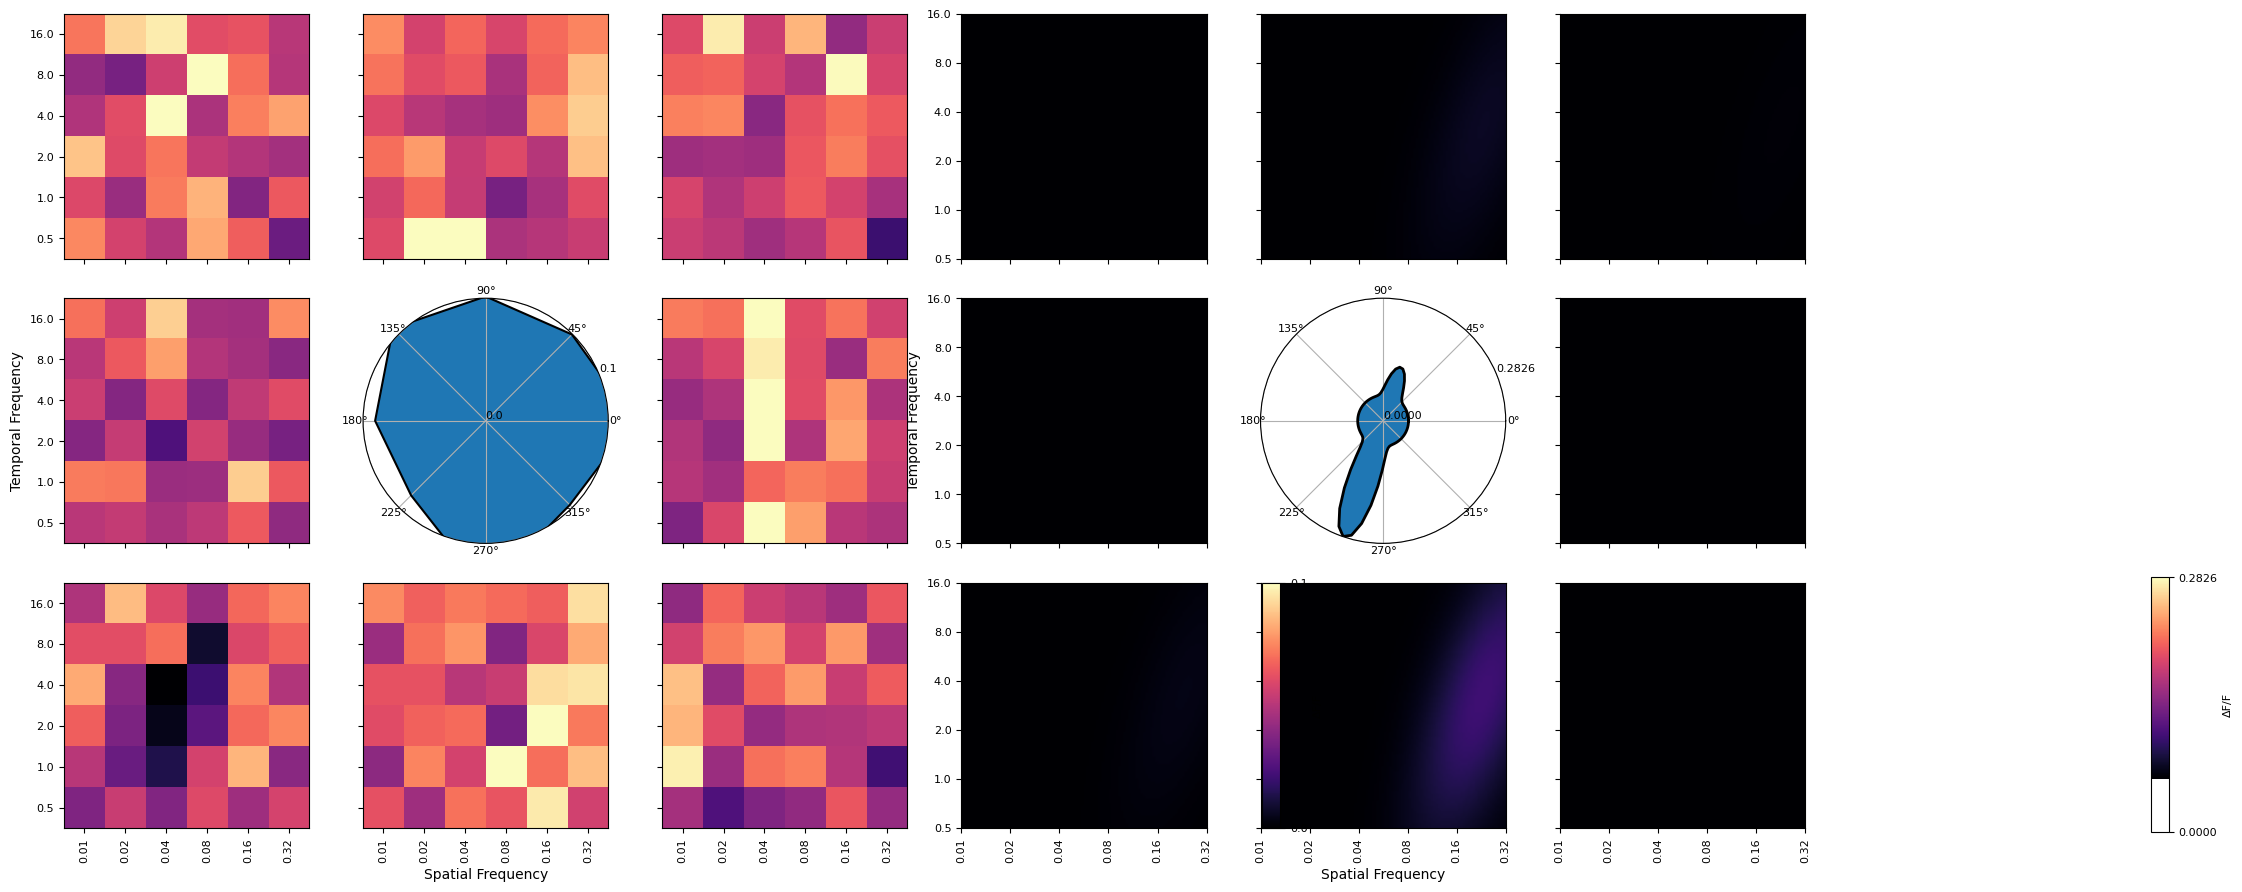

In [18]:
# Create a larger figure for the comparison
plt.figure(figsize=(15, 10))

print(f"Generating full report for ROI {found_rois}...")

grating_plots.basic_vis_SFTF_roi(
    neurons_df=neurons_df,
    trials_df_depth=None,          # No depth data
    trials_df_sftf=trials_df_formatted, # Use the formatted dataframe
    roi=found_rois,
    add_depth=False,
    fontsize_dict={'title': 12, 'label': 10, 'tick': 8}
)

plt.show()

Data already ready.
Filtering: Found 770 selective neurons (R2 > 0.1)

🎯 SHARPEST SPATIAL FREQUENCY TUNING (Smallest Width)
   (These neurons are very picky about bar thickness)
ROI 643: SF Width=-670.89 (Lower is sharper) | Pref=-1.64 cpd | R2=0.11


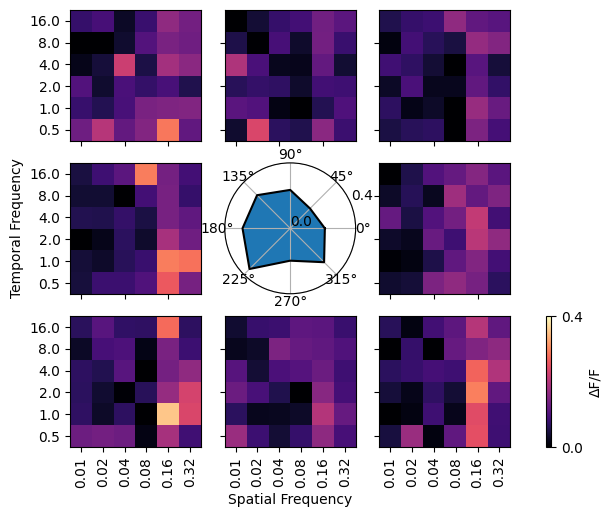

ROI 835: SF Width=-360.48 (Lower is sharper) | Pref=-1.95 cpd | R2=0.13


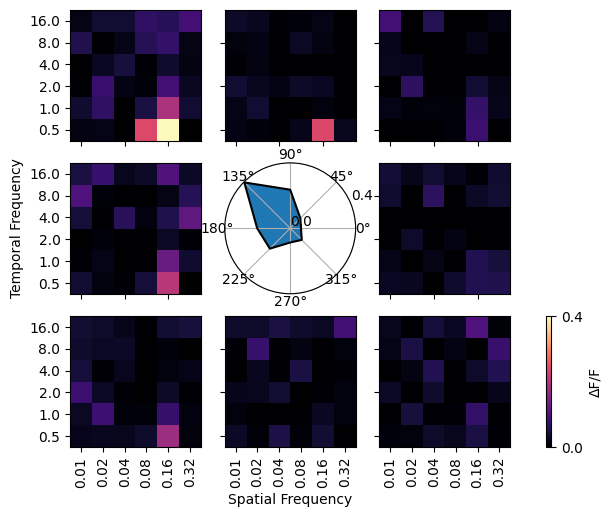

ROI 1961: SF Width=-324.18 (Lower is sharper) | Pref=-1.34 cpd | R2=0.16


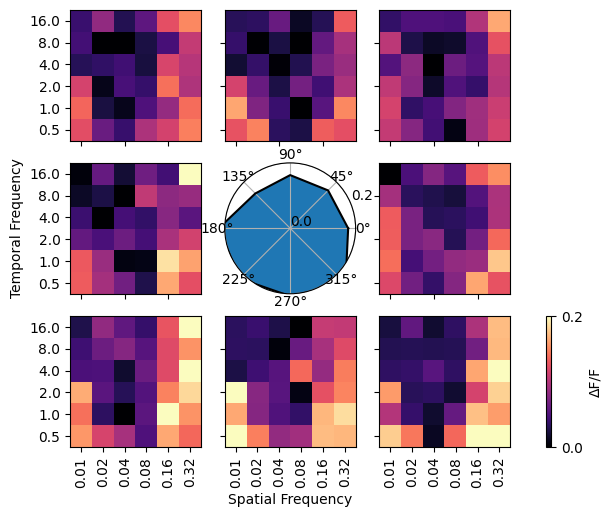

ROI 755: SF Width=-191.48 (Lower is sharper) | Pref=-1.61 cpd | R2=0.16


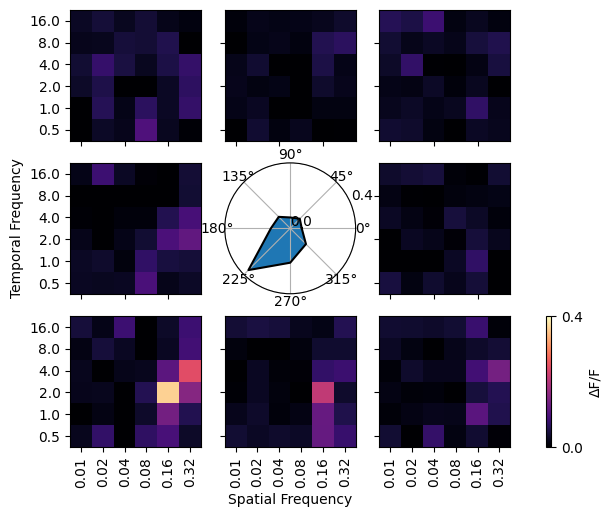

ROI 1192: SF Width=-133.39 (Lower is sharper) | Pref=-1.56 cpd | R2=0.13


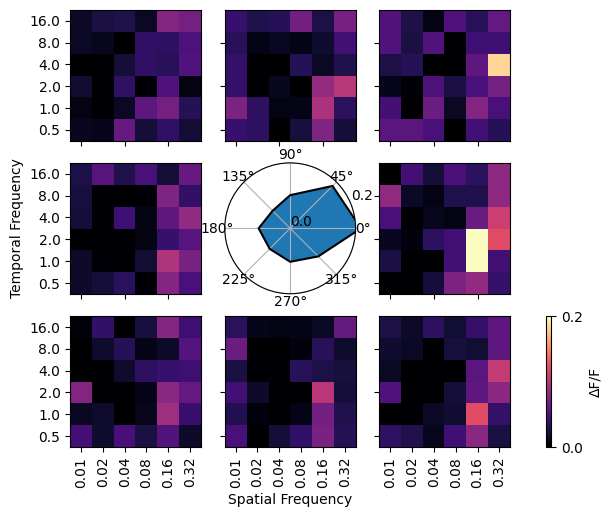


🎯 SHARPEST TEMPORAL FREQUENCY TUNING (Smallest Width)
   (These neurons are very picky about speed)
ROI 777: TF Width=-1220.08 (Lower is sharper) | Pref=1.26 Hz | R2=0.12


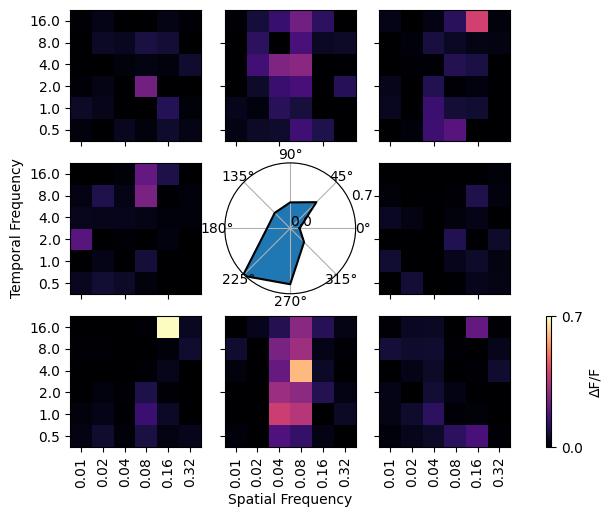

ROI 474: TF Width=-1015.23 (Lower is sharper) | Pref=1.33 Hz | R2=0.20


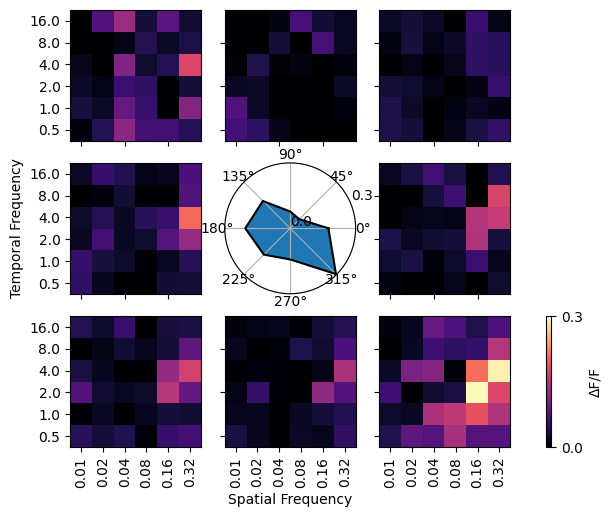

ROI 1198: TF Width=-715.59 (Lower is sharper) | Pref=2.22 Hz | R2=0.14


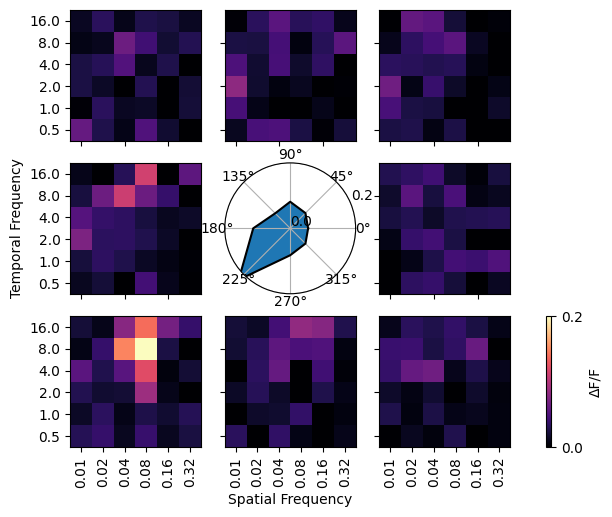

ROI 775: TF Width=-396.82 (Lower is sharper) | Pref=1.21 Hz | R2=0.16


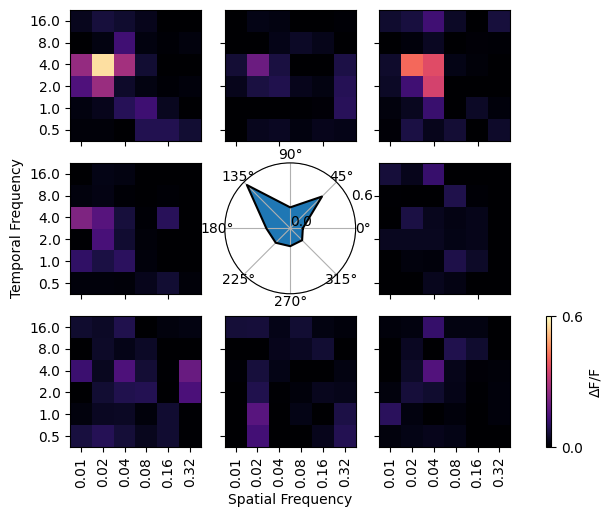

ROI 946: TF Width=-380.46 (Lower is sharper) | Pref=0.96 Hz | R2=0.19


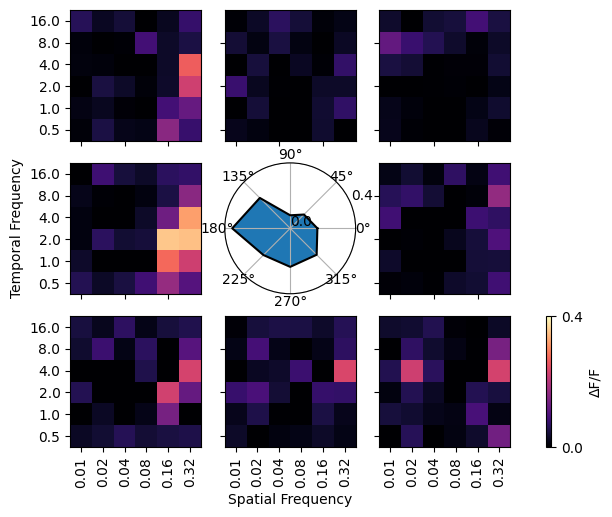


🎯 SHARPEST DIRECTION TUNING (Highest Kappa)
   (These neurons only look in one specific direction)
ROI 1975: Kappa=6.30 (Higher is sharper) | Pref=133° | R2=0.33


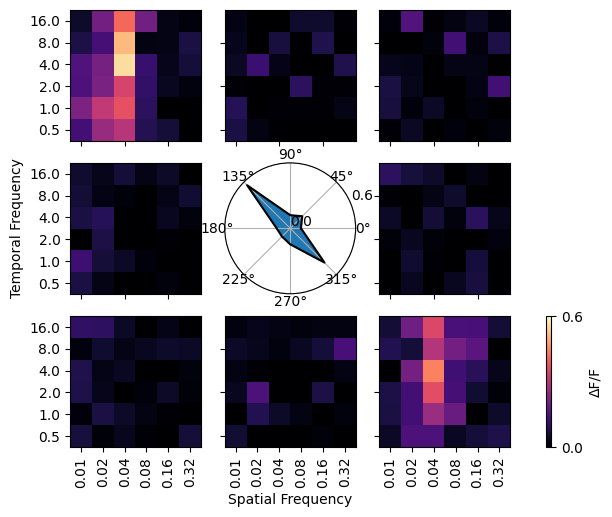

ROI 1478: Kappa=5.39 (Higher is sharper) | Pref=226° | R2=0.11


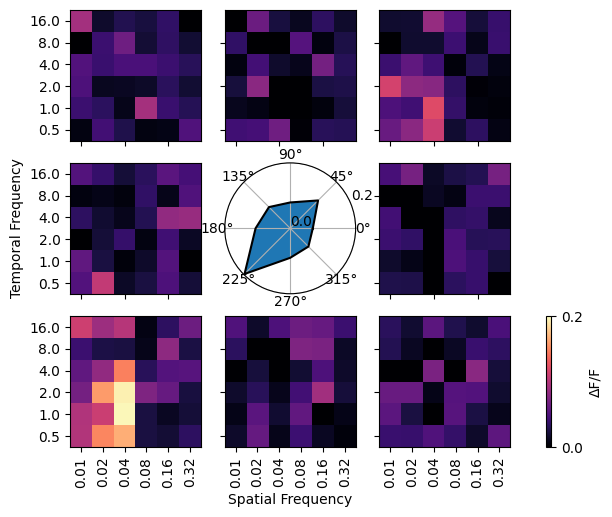

ROI 1711: Kappa=4.74 (Higher is sharper) | Pref=266° | R2=0.28


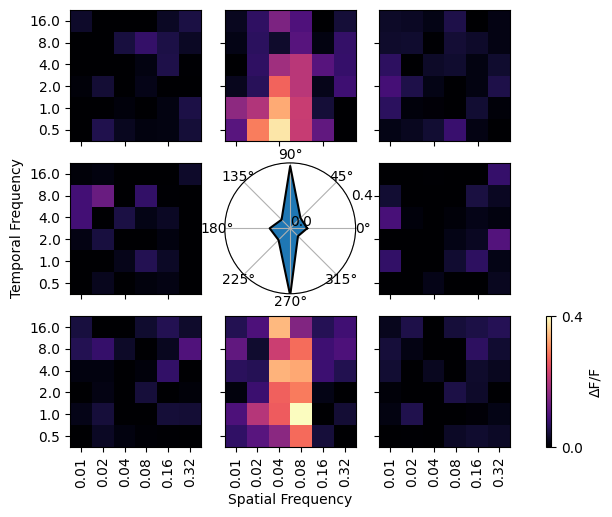

ROI 832: Kappa=4.65 (Higher is sharper) | Pref=233° | R2=0.21


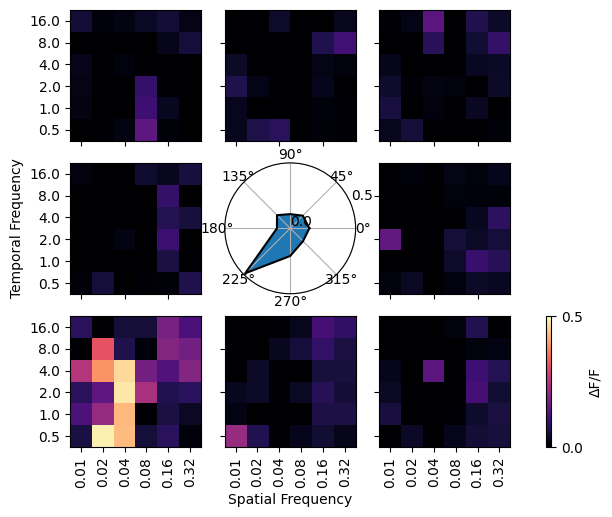

ROI 873: Kappa=4.54 (Higher is sharper) | Pref=314° | R2=0.28


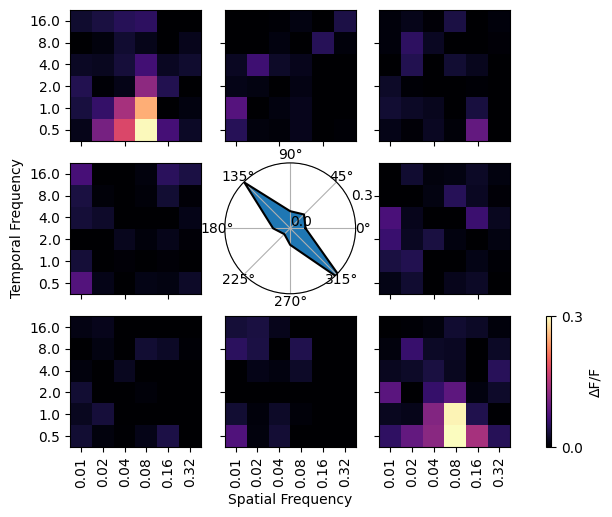

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from cottage_analysis.plotting import grating_plots

base_save_dir = Path("analysis_dataframes")
save_path = base_save_dir / mouse_name / session_name / protocol
neurons_file = save_path / "neurons_df.pkl"

if 'trials_df' not in locals():
    raise FileNotFoundError("'trials_df' is missing from memory. Please run previous kernels.")
if 'neurons_df' not in locals():
    if neurons_file.exists():
        print("Loading neurons_df from disk...")
        neurons_df = pd.read_pickle(neurons_file)
    else:
        raise FileNotFoundError(f"No neurons_df found at {save_path}. Run previous kernels first.")

if 'trials_df_formatted' not in locals():
    print("   Formatting trials dataframe for plotting...")
    response_matrix = np.stack(trials_df['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)
    
    responses_df = pd.DataFrame(
        response_matrix, 
        columns=np.arange(response_matrix.shape[1]), 
        index=trials_df.index
    )
    
    trials_df_formatted = pd.concat(
        [trials_df[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], 
        axis=1
    )
    print("Data formatted and ready.")
else:
    print("Data already ready.")


# --- CONFIGURATION ---
# We use a slightly higher R2 threshold (0.15) here. 
# Why? Very noisy neurons can sometimes generate artificial "single pixel" fits 
# that look infinitely sharp. We want to ensure the response is real first.
quality_threshold = 0.1
top_n_to_plot = 5 

# Filter for real, responsive neurons
good_neurons = neurons_df[neurons_df['rsq'] > quality_threshold].copy()
print(f"Filtering: Found {len(good_neurons)} selective neurons (R2 > {quality_threshold})")


# ==========================================
# 1. SHARPEST SPATIAL FREQUENCY TUNING
# ==========================================
print("\n" + "="*50)
print(f"🎯 SHARPEST SPATIAL FREQUENCY TUNING (Smallest Width)")
print("   (These neurons are very picky about bar thickness)")
print("="*50)

# Sort by Sigma (Width) -> Ascending (Smallest width first)
sf_selective = good_neurons.sort_values(by='log_sigma_x2', ascending=True)

for roi_id in sf_selective.index[:top_n_to_plot]:
    row = neurons_df.loc[roi_id]
    width_score = row['log_sigma_x2']
    print(f"ROI {roi_id}: SF Width={width_score:.2f} (Lower is sharper) | Pref={row['sf0']:.2f} cpd | R2={row['rsq']:.2f}")
    
    plt.figure(figsize=(5, 5))
    grating_plots.plot_sftf_tuning(trials_df=trials_df_formatted, roi=roi_id, plot_grid=True)
    plt.show()


# ==========================================
# 2. SHARPEST TEMPORAL FREQUENCY TUNING
# ==========================================
print("\n" + "="*50)
print(f"🎯 SHARPEST TEMPORAL FREQUENCY TUNING (Smallest Width)")
print("   (These neurons are very picky about speed)")
print("="*50)

# Sort by Sigma Y (TF Width) -> Ascending
tf_selective = good_neurons.sort_values(by='log_sigma_y2', ascending=True)

for roi_id in tf_selective.index[:top_n_to_plot]:
    row = neurons_df.loc[roi_id]
    width_score = row['log_sigma_y2']
    print(f"ROI {roi_id}: TF Width={width_score:.2f} (Lower is sharper) | Pref={row['tf0']:.2f} Hz | R2={row['rsq']:.2f}")
    
    plt.figure(figsize=(5, 5))
    grating_plots.plot_sftf_tuning(trials_df=trials_df_formatted, roi=roi_id, plot_grid=True)
    plt.show()


# ==========================================
# 3. SHARPEST DIRECTION TUNING
# ==========================================
print("\n" + "="*50)
print(f"🎯 SHARPEST DIRECTION TUNING (Highest Kappa)")
print("   (These neurons only look in one specific direction)")
print("="*50)

# Sort by Kappa (Concentration) -> Descending (Higher is sharper)
dir_selective = good_neurons.sort_values(by='log_kappa', ascending=False)

for roi_id in dir_selective.index[:top_n_to_plot]:
    row = neurons_df.loc[roi_id]
    kappa_score = row['log_kappa']
    deg = np.degrees(row['alpha0']) % 360
    print(f"ROI {roi_id}: Kappa={kappa_score:.2f} (Higher is sharper) | Pref={deg:.0f}° | R2={row['rsq']:.2f}")
    
    plt.figure(figsize=(5, 5))
    grating_plots.plot_sftf_tuning(trials_df=trials_df_formatted, roi=roi_id, plot_grid=True)
    plt.show()